## Monte Carlo Simulation
### American Express — EMV Chip Transition Risk Assessment
### ALY6130 Risk Management Analytics | Winter 2026

This notebook applies Monte Carlo simulation to model uncertainty
and variability in risk outcomes for the three priority risks
identified in the American Express EMV chip transition assessment.

Building on the probability and expected impact values calculated
in the quantitative analysis notebook, we run 10,000 simulations
for each risk to produce a distribution of possible outcomes
rather than relying on a single fixed risk score.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Risk register data from Assignment 3
data = {
    'Risk #':           ['R-001', 'R-002', 'R-003', 'R-004', 'R-005', 'R-006'],
    'Risk Type':        ['Financial', 'Operational', 'Competitive',
                         'Reputational', 'Legal/Compliance', 'Operational'],
    'Likelihood Score': [7, 7, 9, 5, 7, 7],
    'Impact Score':     [8, 6, 8, 8, 6, 6],
    'Risk Score':       [56, 42, 72, 40, 42, 42]
}

df = pd.DataFrame(data)

# Calculate Probability and Expected Impact
df['Probability (%)'] = round((df['Likelihood Score'] / 9) * 100, 2)
df['Expected Impact'] = round((df['Likelihood Score'] / 9) * (df['Impact Score'] / 9), 4)

print("=== PROBABILITY AND EXPECTED IMPACT ===\n")
print(df[['Risk #', 'Risk Type', 'Likelihood Score',
          'Impact Score', 'Probability (%)', 'Expected Impact']].to_string(index=False))


=== PROBABILITY AND EXPECTED IMPACT ===

Risk #        Risk Type  Likelihood Score  Impact Score  Probability (%)  Expected Impact
 R-001        Financial                 7             8            77.78           0.6914
 R-002      Operational                 7             6            77.78           0.5185
 R-003      Competitive                 9             8           100.00           0.8889
 R-004     Reputational                 5             8            55.56           0.4938
 R-005 Legal/Compliance                 7             6            77.78           0.5185
 R-006      Operational                 7             6            77.78           0.5185


Monte Carlo simulation runs 10,000 random scenarios for each risk.
Instead of relying on a single fixed risk score, it shows the full
 range of possible outcomes based on the probability and impact values
 we already calculated from the risk register.


In [2]:
np.random.seed(42)
n_simulations = 10000

# Use only the 3 priority risks
priority_risks = df[df['Risk #'].isin(['R-001', 'R-002', 'R-003'])].copy()

mc_results = {}

for _, row in priority_risks.iterrows():
    prob  = row['Likelihood Score'] / 9
    impact = row['Impact Score'] / 9

    # Simulate random variation around known probability and impact
    prob_samples   = np.random.normal(prob, 0.05, n_simulations).clip(0, 1)
    impact_samples = np.random.normal(impact, 0.05, n_simulations).clip(0, 1)

    # Scale back to 1-81 risk score range
    simulated_scores = prob_samples * impact_samples * 81

    mc_results[row['Risk #']] = {
        'Risk Type':       row['Risk Type'],
        'Scores':          simulated_scores,
        'Mean':            round(np.mean(simulated_scores), 2),
        'Median':          round(np.median(simulated_scores), 2),
        'Best Case (5%)':  round(np.percentile(simulated_scores, 5), 2),
        'Worst Case (95%)':round(np.percentile(simulated_scores, 95), 2)
    }



In [3]:
# Print summary
print("=== MONTE CARLO SIMULATION RESULTS (10,000 runs) ===\n")
for risk, res in mc_results.items():
    print(f"{risk} — {res['Risk Type']}")
    print(f"  Mean Score:        {res['Mean']}")
    print(f"  Median Score:      {res['Median']}")
    print(f"  Best Case  (5%):   {res['Best Case (5%)']}")
    print(f"  Worst Case (95%):  {res['Worst Case (95%)']}\n")


=== MONTE CARLO SIMULATION RESULTS (10,000 runs) ===

R-001 — Financial
  Mean Score:        56.02
  Median Score:      55.91
  Best Case  (5%):   48.39
  Worst Case (95%):  64.03

R-002 — Operational
  Mean Score:        41.94
  Median Score:      41.87
  Best Case  (5%):   35.28
  Worst Case (95%):  48.93

R-003 — Competitive
  Mean Score:        70.56
  Median Score:      70.62
  Best Case  (5%):   63.08
  Worst Case (95%):  77.81



### Interpretation

The Monte Carlo simulation confirms the priority ranking from
the qualitative heat map. R-003 (Merchant Acceptance) has the
highest mean simulated score of 70.56, followed by R-001
(CNP Fraud) at 56.02 and R-002 (Terminal Delays) at 41.94.

Even in the best case scenario at the 5th percentile, R-003
and R-001 remain in the High severity zone, confirming they
require immediate and sustained mitigation action.

R-002 approaches the High threshold of 54 in the worst case
scenario at the 95th percentile, signaling escalation risk
under adverse conditions.

Monte Carlo Distribution Charts

 - Each chart shows the spread of 10,000 simulated risk scores.
 - The blue line marks the average score.
 - The red line marks the worst case (95th percentile).

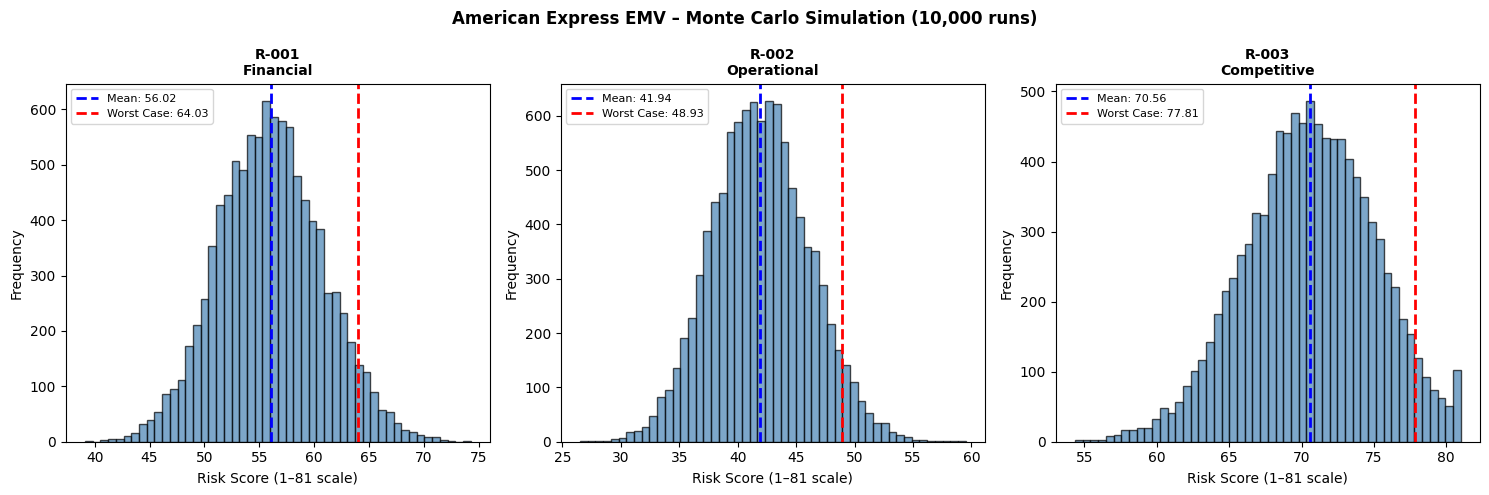

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (risk, res) in zip(axes, mc_results.items()):
    ax.hist(res['Scores'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(res['Mean'], color='blue', linestyle='--',
               linewidth=2, label=f"Mean: {res['Mean']}")
    ax.axvline(res['Worst Case (95%)'], color='red', linestyle='--',
               linewidth=2, label=f"Worst Case: {res['Worst Case (95%)']}")
    ax.set_title(f"{risk}\n{res['Risk Type']}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Risk Score (1–81 scale)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('American Express EMV – Monte Carlo Simulation (10,000 runs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### References

Jalilvand, A., & Moorthy, S. (2023). Triangulating risk profile
and risk assessment. Journal of Risk and Financial Management,
16(11), 473. https://doi.org/10.3390/jrfm16110473

Pape, C. (2025). Visa, Mastercard settle merchant suit for
nearly $200M. American Banker.
https://www.americanbanker.com/payments/news/visa-mastercard-settle-merchant-suit-for-nearly-200m

Fitzgerald, K. (2016). Why EMV failed to meet terminal makers'
expectations. American Banker.
https://www.americanbanker.com/payments/news/why-emv-failed-to-meet-terminal-makers-expectations